# Large Phasor Model (LPM) for Timeseries Analysis

This notebook implements a generative autoregressive language-model-style architecture strictly optimized for continuous sequence prediction via deep stack parameter processing in Phase domain.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))
import phasorflow as pf
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

np.random.seed(42)
torch.manual_seed(42)

## 1. Timeseries Data Generation

We build an explicit autoregressive dataset out of composite sequences where input is length $T$ and the generative objective label is step $T+1$.

In [2]:
time_steps = 300
T = 16 # Sequence Context Window Length

# Generate complex base oscillation waveform (composite of 4 structural interacting frequencies)
t_axis = np.linspace(0, 15 * np.pi, time_steps)
signal = (np.sin(t_axis) + 
          0.6 * np.cos(3.2 * t_axis) + 
          0.3 * np.sin(7.1 * t_axis) + 
          0.15 * np.cos(14 * t_axis))

# Add standard noise limit
signal += np.random.normal(0, 0.05, time_steps)

# Frame into (X, y) auto-regressive context prompting predictions
X_seq = []
y_seq = []

for i in range(len(signal) - T):
    X_seq.append(signal[i:i+T])
    y_seq.append(signal[i+T])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

# Linear Encoding to Unit Circle [-pi/2, pi/2]
max_val = np.max(np.abs(signal))
X_seq_norm = (X_seq / max_val) * (np.pi / 2)
y_seq_norm = (y_seq / max_val) * (np.pi / 2)

# Split into Train / Test (80/20)
split = int(len(X_seq) * 0.8)
X_train = torch.tensor(X_seq_norm[:split], dtype=torch.float32)
y_train = torch.tensor(y_seq_norm[:split], dtype=torch.float32)
X_test = torch.tensor(X_seq_norm[split:], dtype=torch.float32)
y_test = torch.tensor(y_seq_norm[split:], dtype=torch.float32)

print(f"Generated {X_train.shape[0]} Training Sequences and {X_test.shape[0]} Test Sequences of length T={T}")

Generated 227 Training Sequences and 57 Test Sequences of length T=16


## 2. LPM FNet Stack Construction

We allow scaling N blocks. Each block takes $2T$ parameters.

In [3]:
num_blocks = 3  # Start with D=3 deep stack

def build_lpm(x_seq, weights):
    pc = pf.PhasorCircuit(T, name="LPM")
    
    # Context Data Injection (Encoder Tokens)
    for i in range(T):
        pc.shift(i, x_seq[i])
        
    weight_idx = 0
    
    # Iterative FNet Layer Stack
    for block in range(num_blocks):
        # Pre-FFN Projection
        for i in range(T):
            pc.shift(i, weights[weight_idx + i])
        weight_idx += T
        
        # Token Mixing (Global Thread Frequencies)
        pc.dft()
        
        # Post-FFN Projection
        for i in range(T):
            pc.shift(i, weights[weight_idx + i])
        weight_idx += T
        
    # Optional sequence readout smoothing layer
    for i in range(T):
        pc.shift(i, weights[weight_idx + i])
        
    return pc

backend = pf.Simulator.get_backend('analytic_simulator')

def predict_step(x_seq, weights):
    pc = build_lpm(x_seq, weights)
    res = backend.run(pc)
    
    # Target value is the final prediction extracted from Thread 0
    # Apply continuous structural geometric limit mapping using Autograd-safe remainder
    raw_angle = res['phases'][0]
    wrapped_prediction = torch.asin(torch.sin(raw_angle))
    return wrapped_prediction

# Preview Untrained output
total_weights = (num_blocks * 2 * T) + T
print(f"LPM Parameter Count: {total_weights}")
initial_weights = torch.empty(total_weights).uniform_(-np.pi/10, np.pi/10).requires_grad_()
print("Untrained Step Prediction:", predict_step(X_train[0], initial_weights).item())

LPM Parameter Count: 112
Untrained Step Prediction: 1.3544485569000244


## 3. LPM Training Optimization

We optimize the next-token prediction parameters through standard BFGS.

In [4]:
def calculate_loss(weights):
    predictions = torch.stack([predict_step(x, weights) for x in X_train])
    loss = torch.mean((predictions - y_train)**2)
    return loss

initial_loss = calculate_loss(initial_weights)
print(f"Starting Base Loss: {initial_loss.item():.4f}")

optimizer = optim.Adam([initial_weights], lr=0.05)
EPOCHS = 100

for epoch in range(EPOCHS):
    optimizer.zero_grad()
    loss = calculate_loss(initial_weights)
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f}")

optimal_weights_tensor = initial_weights.detach()
print(f"\nOptimized LPM Base Loss: {loss.item():.4f}")

# Save the trained Large Phasor Model!
np.save("lpm_weights.npy", optimal_weights_tensor.numpy())
print("Saved LPM Parameters to 'lpm_weights.npy'")

Starting Base Loss: 1.0519


Epoch   0 | Loss: 1.0519


Epoch  10 | Loss: 0.4485


Epoch  20 | Loss: 0.3385


Epoch  30 | Loss: 0.1789


...

Epoch  60 | Loss: 0.0410


Epoch  70 | Loss: 0.0333


Epoch  80 | Loss: 0.0315


Epoch  90 | Loss: 0.0307



Optimized LPM Base Loss: 0.0291
Saved LPM Parameters to 'lpm_weights.npy'


## 4. Test Error & Generative Autoregressive Inference

We validate the context bounds and evaluate if the model tracks true structures recursively!

Test Set Prediction MSE: 0.1095


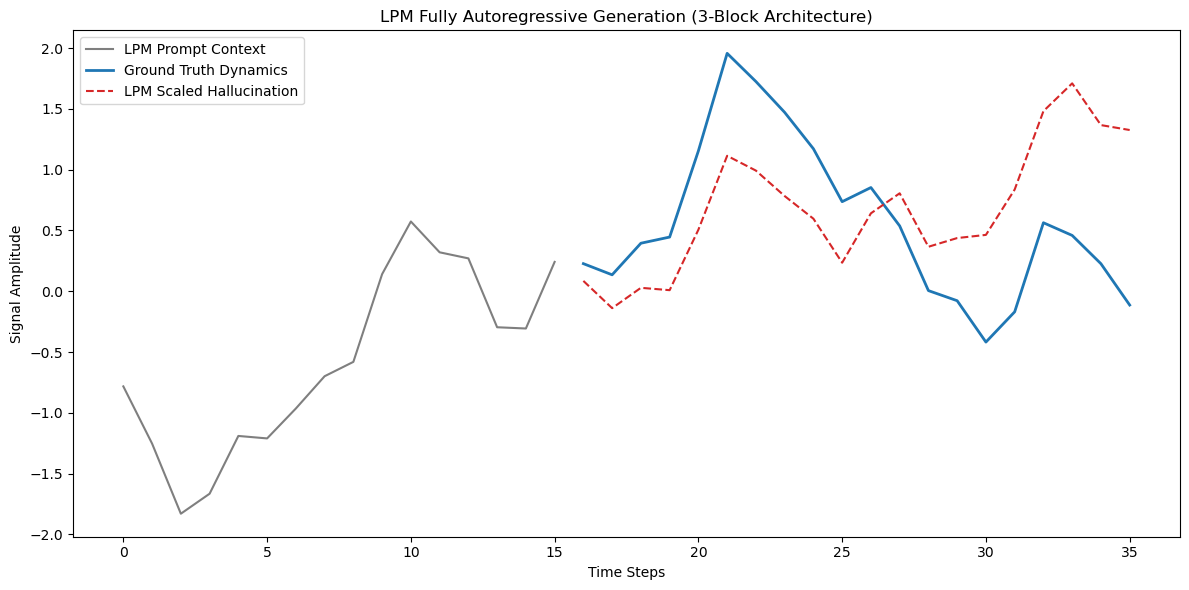

In [5]:
# 1. Standard Testing Error
with torch.no_grad():
    test_predictions_norm = torch.stack([predict_step(x, optimal_weights_tensor) for x in X_test])
    final_test_mse = torch.mean((test_predictions_norm - y_test)**2).item()
print(f"Test Set Prediction MSE: {final_test_mse:.4f}")

# De-normalize predictions to domain
test_predictions_true = (test_predictions_norm * max_val / (np.pi / 2)).numpy()
y_test_true = (y_test * max_val / (np.pi / 2)).numpy()

# 2. Fully Autoregressive Rolling Generation!
gen_horizon = 20 # Number of steps to independently hallucinate structures into the future
context_prompt = X_test[0].clone()

rolling_predictions_norm = []

with torch.no_grad():
    for _ in range(gen_horizon):
        next_step = predict_step(context_prompt, optimal_weights_tensor)
        rolling_predictions_norm.append(next_step)
        
        # Roll Context Prompt Window
        context_prompt = torch.roll(context_prompt, -1)
        context_prompt[-1] = next_step

rolling_predictions_true = (torch.stack(rolling_predictions_norm).numpy()) * max_val / (np.pi / 2)

# Capture matching ground truth elements extending beyond standard X_test context limits
start_idx = split
y_ground_truth_future = y_seq[start_idx : start_idx + gen_horizon]
x_sample_context = X_seq[start_idx]

plt.figure(figsize=(12, 6))
plt.plot(range(T), x_sample_context, label="LPM Prompt Context", color='tab:gray', linestyle='-')
plt.plot(range(T, T + gen_horizon), y_ground_truth_future, label="Ground Truth Dynamics", color='tab:blue', linewidth=2)
plt.plot(range(T, T + gen_horizon), rolling_predictions_true, label="LPM Scaled Hallucination", color='tab:red', linestyle='--')
plt.title(f"LPM Fully Autoregressive Generation ({num_blocks}-Block Architecture)")
plt.xlabel("Time Steps")
plt.ylabel("Signal Amplitude")
plt.legend()
plt.tight_layout()
plt.show()